In [1]:
from ml_enhance import QuantumFPFileLoader, QFPFeatureEngineer, ConformerAggregator, QuantumFPDatasetBuilder, RDKitFeatureCalculator
from collections import Counter
import matplotlib.pyplot as plt
from pathlib import Path
from rdkit import Chem
import pandas as pd
import numpy as np
import json
import os

In [2]:
OUTPUT_PATH = Path("../data/QuantumFP/QFP_output")

loader = QuantumFPFileLoader(OUTPUT_PATH)
output_files = loader.list_output_files()

# get QFP directory path
output_files_numbers: list[Path] = [int(path.name.split('.')[0].split('_')[-1]) for path in output_files]

print((output_files_numbers))

[0, 1, 10, 100, 1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 101, 1010, 1011, 1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 102, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 103, 1030, 1031, 1032, 1033, 1034, 1035, 1036, 1037, 1038, 1039, 104, 1040, 1041, 1042, 1043, 1044, 1045, 1046, 1047, 1048, 1049, 105, 1050, 1051, 1052, 1053, 1054, 1055, 1056, 1057, 1058, 1059, 106, 1060, 1061, 1062, 1063, 1064, 1065, 1066, 1067, 1068, 1069, 107, 1070, 1071, 1072, 1073, 1074, 1075, 1076, 1077, 1078, 1079, 108, 1080, 1081, 1082, 1083, 1084, 1085, 1086, 1087, 1088, 1089, 109, 1090, 1091, 1092, 1093, 1094, 1095, 1096, 1097, 1098, 1099, 11, 110, 1100, 1101, 1102, 1103, 1104, 1105, 1106, 1107, 1108, 1109, 111, 1110, 1111, 1112, 1113, 1114, 1115, 1116, 1117, 1118, 1119, 112, 1120, 1121, 1122, 1123, 1124, 1125, 1126, 1127, 1128, 1129, 113, 1130, 1131, 1132, 1133, 1134, 1135, 1136, 1137, 1138, 1139, 114, 1140, 1141, 1142, 1143, 1144, 1145, 1146, 1147, 1148, 1149, 115, 1150,

In [3]:
output_files_numbers[587]

1527

In [3]:
for df in loader.stream_conformer_dataframe(OUTPUT_PATH / "internship_smiles2_0.json.gz"):
    print(df["partial_charge"])

0    [[1, 0.40345778309363234], [2, -0.276498655228...
Name: partial_charge, dtype: object


In [3]:
missing = [i for i in range(8845) if i not in output_files_numbers]
print(missing)

[895, 1226, 1611, 1650, 2094, 2216, 5262, 5882]


In [4]:
builder = QuantumFPDatasetBuilder(OUTPUT_PATH)
df, errors = builder.build_dataset(cap=200, multiprocess=True, n_jobs=4)

  4%|▍         | 8/200 [00:01<00:41,  4.58it/s]

KeyboardInterrupt: 

In [14]:
errors

[]

In [15]:
rdkit_calc = RDKitFeatureCalculator()
complete_df = rdkit_calc.add_to_dataframe(df)

In [16]:
complete_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Columns: 273 entries, smiles to fr_urea
dtypes: float64(162), int64(110), object(1)
memory usage: 426.7+ KB


In [ ]:
used_smiles = complete_df["smiles"].values
len(used_smiles)

50

In [15]:
unwanted_atoms = ['Cd', 'W', 'Te', 'Mn', 'Nb', 'Cr', 'Sb', 'Ge', 'Ca', 'Bi', 'Y', 'Al', 'Sr', 'Fe', 'Ni', 'Ti', 'Zr', 'Be', 'Ce', 'Hg']
len(unwanted_atoms)

20

In [16]:
total_atom_types = []
count = 0
for smiles in used_smiles:
    mol = Chem.MolFromSmiles(smiles)

    mol_atom_types = [atom.GetSymbol() for atom in mol.GetAtoms()]

    if any(atom in unwanted_atoms for atom in mol_atom_types):
        count += 1
    else:
        total_atom_types.extend(mol_atom_types)

In [17]:
print(count)

0


In [18]:
print(Counter(total_atom_types))

Counter({'C': 797, 'O': 112, 'N': 48, 'F': 26, 'Cl': 14, 'Co': 3, 'P': 2, 'Sn': 2, 'S': 2, 'Si': 2, 'B': 1, 'Br': 1})


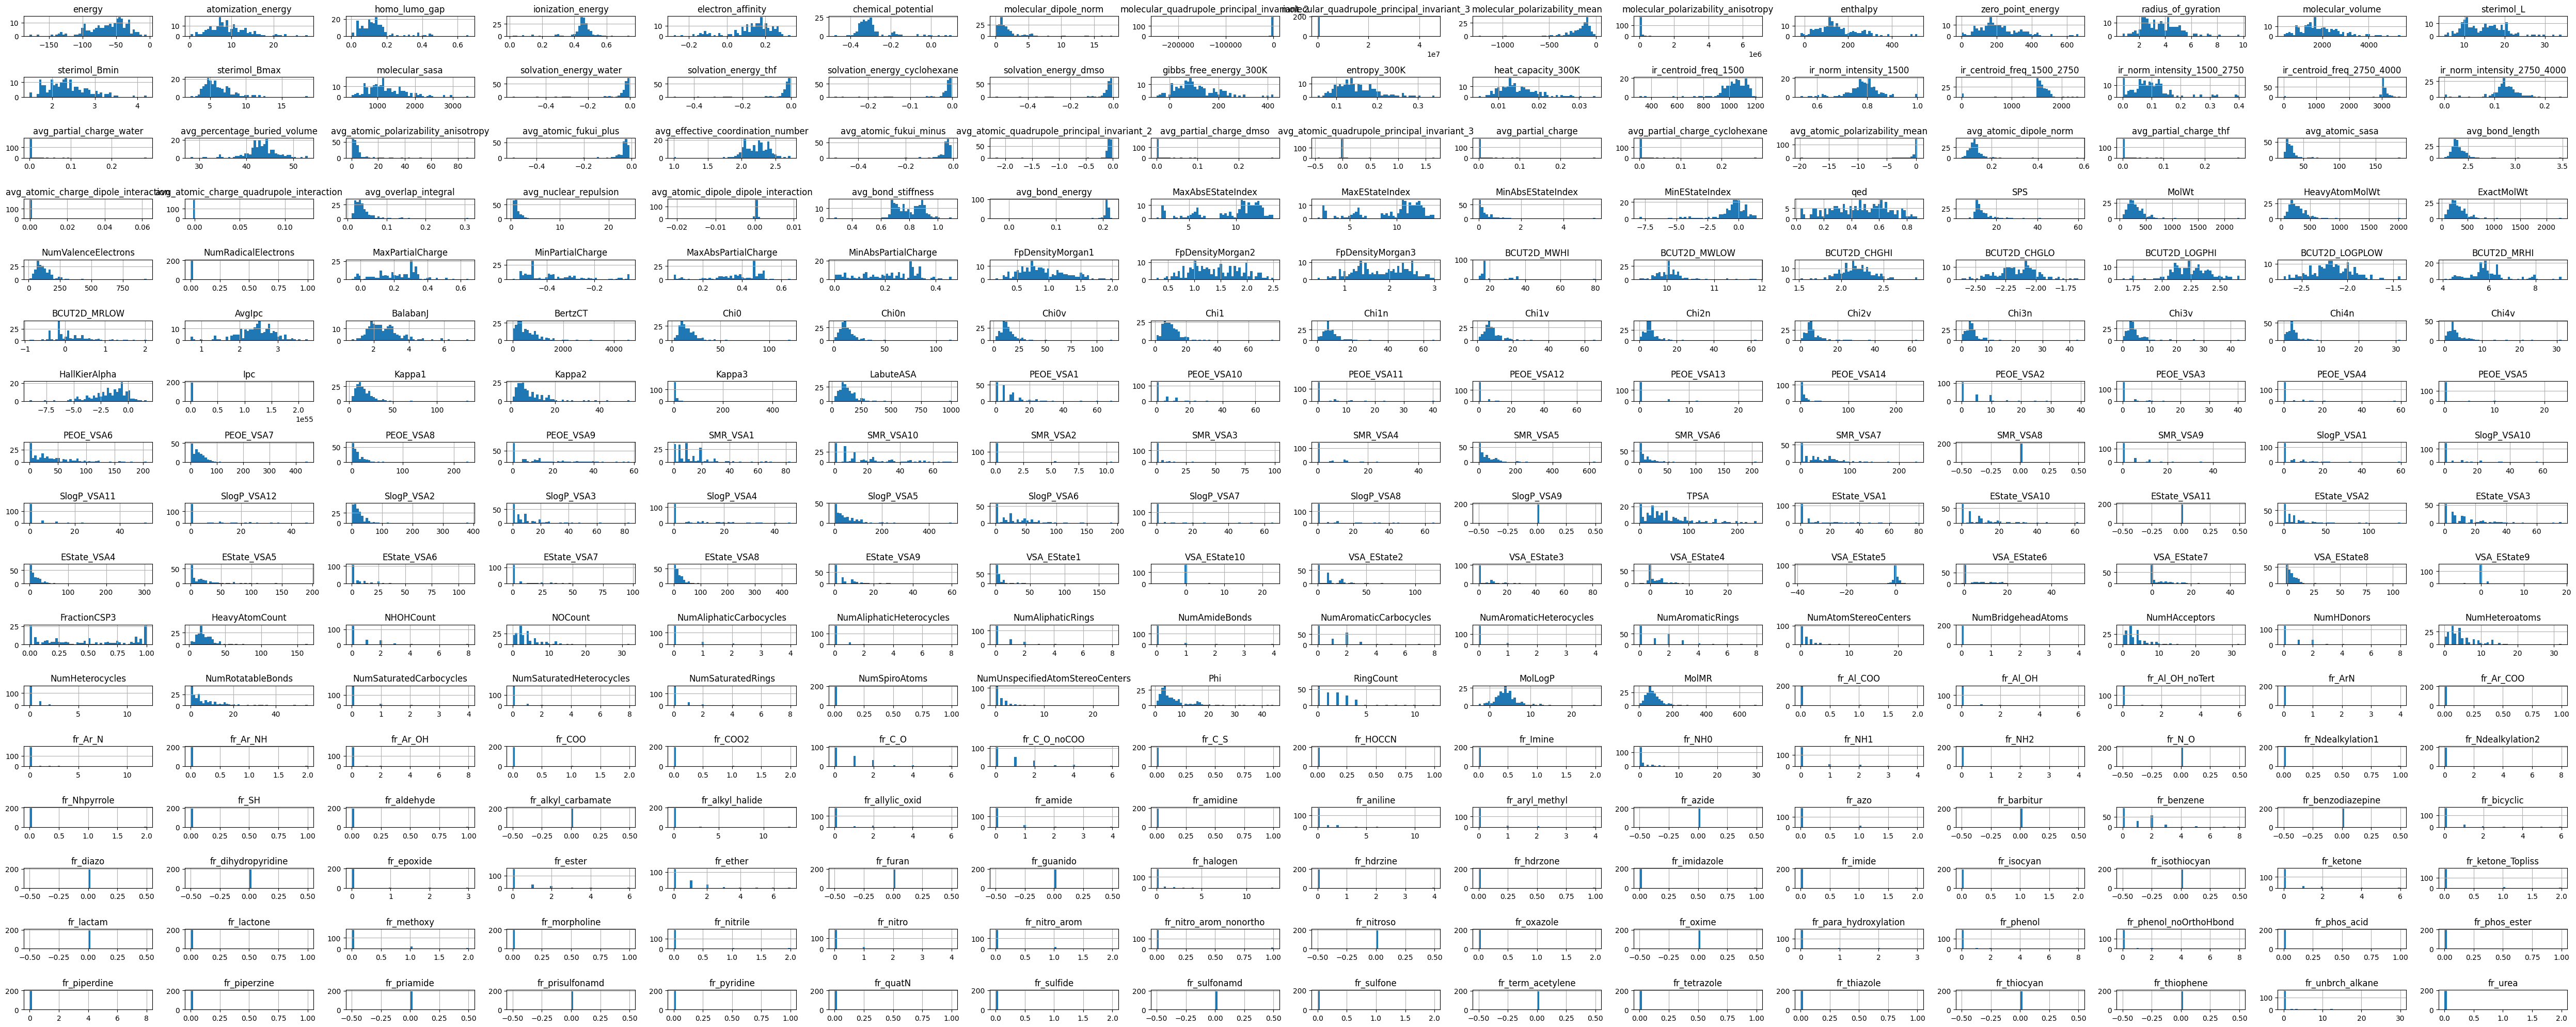

In [18]:
subset_feature_df = complete_df.drop("smiles", axis=1)
subset_feature_df.hist(bins=50, figsize=(50,20))
plt.tight_layout()
plt.grid(False)
plt.show()

In [24]:
def count_zeros(file):
    count_list = []
    for df in loader.stream_conformer_dataframe(file):
        print(file)
        if len(df["bond_energy"][0]) == 0:
            count_list.append(df["original_smiles"])
    
    return count_list

In [ ]:
import os
import gzip
import json

def check_file(file):
    corrupted_files = []
    try:
        for df in loader.stream_conformer_dataframe(file):
            pass
    except Exception as e:
        corrupted_files.append((file, str(e)))

    return corrupted_files

def check_json_gz_files(output_files):
    corrupted_files = []

    corrupted_list = parallelize(check_file, output_files)
    if len(corrupted_list) > 0:
        corrupted_files.append(*corrupted_list)
    
    return corrupted_files

    # if corrupted:
    #     print("Corrupted or invalid JSON.GZ files:\n")
    #     for path in corrupted:
    #         print(f"{path}\n  Error: {error}\n")
    # else:
    #     print("All .json.gz files are valid.")

check_json_gz_files(output_files)

100%|██████████| 8837/8837 [25:58<00:00,  5.67it/s]  


[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [(WindowsPath('../data/QuantumFP/QFP_output/internship_smiles2_1106.json.gz'), "[Errno 2] No such file or directory: '..\\\\data\\\\QuantumFP\\\\QFP_output\\\\internship_smiles2_1106.json.gz'")], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [(WindowsPath('../data/QuantumFP/QFP_output/internship_